In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
NUMBER_OF_SATELLITES_PER_ORBIT = 22

In [3]:
df = pd.read_csv('../generated/2024_04_17,15_02_07#Starlink#100ms#3000s.csv')
df

,TimeStamp,satelliteId,orbitId,X,Y,Z,Anomaly
0,0,Starlink-0-21,550km-0'-53',6.647497e+06,-1.174671e+06,-1.558842e+06,5.997586
1,0,Starlink-1-9,550km-5'-53',-6.429031e+06,1.176203e+06,2.298514e+06,2.713194
2,0,Starlink-0-9,550km-0'-53',-5.828318e+06,2.254178e+06,2.991395e+06,2.570394
3,0,Starlink-0-1,550km-0'-53',6.647497e+06,1.174671e+06,1.558842e+06,0.285599
4,0,Starlink-1-19,550km-5'-53',5.453982e+06,-2.263681e+06,-3.623380e+06,5.569187
...,...,...,...,...,...,...,...
1980061,3000000,Starlink-0-13,550km-0'-53',5.099594e+06,2.822326e+06,3.745353e+06,7.026735
1980062,3000000,Starlink-2-10,550km-10'-53',6.860994e+06,7.313356e+05,-6.252692e+05,6.169937
1980063,3000000,Starlink-0-8,550km-0'-53',5.367704e+06,-2.636115e+06,-3.498243e+06,5.598739
1980064,3000000,Starlink-1-18,550km-5'-53',-4.939327e+06,2.648600e+06,4.072717e+06,8.597532


In [4]:
base_satellite = np.random.choice(df['satelliteId'].unique())
other_satellites = np.array([])
for orbit in df['orbitId'].unique():
    other_satellites = np.append(other_satellites, np.random.choice(df[df.orbitId == orbit].satelliteId.unique()))
print(base_satellite)
print(other_satellites)

Starlink-2-18
['Starlink-0-20' 'Starlink-1-0' 'Starlink-2-13']


In [5]:
base_sattelite_positions = df[df.satelliteId == base_satellite].reset_index()[['TimeStamp', 'X', 'Y', 'Z']]
distance_suffixes = []
for other_satellite in other_satellites:
    other_satellite_positions = df[df.satelliteId == other_satellite].reset_index()
    other_satellite_orbit = other_satellite_positions.orbitId.unique()[0]
    other_satellite_positions = other_satellite_positions[['TimeStamp', 'X', 'Y', 'Z']]
    base_sattelite_positions = pd.merge(base_sattelite_positions, other_satellite_positions, on='TimeStamp', suffixes=('', f"_{other_satellite_orbit}"))
    distance_suffixes.append(f"distance_{other_satellite_orbit}")
    base_sattelite_positions[f"distance_{other_satellite_orbit}"] = base_sattelite_positions.apply(
    lambda row: np.sqrt((row[f'X_{other_satellite_orbit}'] - row[f'X'])**2 + 
                      (row[f'Y_{other_satellite_orbit}'] - row[f'Y'])**2 + 
                      (row[f'Z_{other_satellite_orbit}'] - row[f'Z'])**2), axis=1)  

base_sattelite_positions

,TimeStamp,X,Y,Z,X_550km-0'-53',Y_550km-0'-53',Z_550km-0'-53',distance_550km-0'-53',X_550km-5'-53',Y_550km-5'-53',Z_550km-5'-53',distance_550km-5'-53',X_550km-10'-53',Y_550km-10'-53',Z_550km-10'-53',distance_550km-10'-53'
0,0,3.492918e+06,-3.235283e+06,-5.033044e+06,5.828318e+06,-2.254178e+06,-2.991395e+06,3.253458e+06,6.779805e+06,1.188798e+06,7.874358e+05,8.015866e+06,-5.348339e+06,-3.232009e+06,-2.991395e+06,9.073927e+06
1,100,3.493570e+06,-3.234973e+06,-5.032790e+06,5.828732e+06,-2.253790e+06,-2.990881e+06,3.253474e+06,6.779657e+06,1.189243e+06,7.880408e+05,8.015867e+06,-5.347864e+06,-3.232318e+06,-2.991909e+06,9.073927e+06
2,200,3.494222e+06,-3.234664e+06,-5.032536e+06,5.829145e+06,-2.253403e+06,-2.990367e+06,3.253489e+06,6.779509e+06,1.189687e+06,7.886457e+05,8.015868e+06,-5.347389e+06,-3.232628e+06,-2.992423e+06,9.073927e+06
3,300,3.494874e+06,-3.234355e+06,-5.032282e+06,5.829559e+06,-2.253015e+06,-2.989852e+06,3.253505e+06,6.779360e+06,1.190132e+06,7.892507e+05,8.015870e+06,-5.346914e+06,-3.232938e+06,-2.992938e+06,9.073927e+06
4,400,3.495527e+06,-3.234045e+06,-5.032027e+06,5.829973e+06,-2.252628e+06,-2.989338e+06,3.253521e+06,6.779212e+06,1.190577e+06,7.898556e+05,8.015871e+06,-5.346439e+06,-3.233247e+06,-2.993452e+06,9.073927e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29996,2999600,-4.451657e+06,2.708602e+06,4.565663e+06,-6.383151e+06,1.620933e+06,2.151050e+06,3.277812e+06,-6.450317e+06,-1.859872e+06,-1.712701e+06,8.017696e+06,4.534304e+06,3.664008e+06,3.743553e+06,9.073927e+06
29997,2999700,-4.452234e+06,2.708236e+06,4.565318e+06,-6.383448e+06,1.620508e+06,2.150487e+06,3.277827e+06,-6.450043e+06,-1.860288e+06,-1.713282e+06,8.017697e+06,4.533735e+06,3.664252e+06,3.744003e+06,9.073927e+06
29998,2999800,-4.452810e+06,2.707870e+06,4.564973e+06,-6.383746e+06,1.620084e+06,2.149924e+06,3.277842e+06,-6.449768e+06,-1.860703e+06,-1.713863e+06,8.017698e+06,4.533166e+06,3.664496e+06,3.744453e+06,9.073927e+06
29999,2999900,-4.453387e+06,2.707504e+06,4.564627e+06,-6.384043e+06,1.619660e+06,2.149361e+06,3.277858e+06,-6.449494e+06,-1.861119e+06,-1.714444e+06,8.017699e+06,4.532597e+06,3.664740e+06,3.744903e+06,9.073927e+06


array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object)

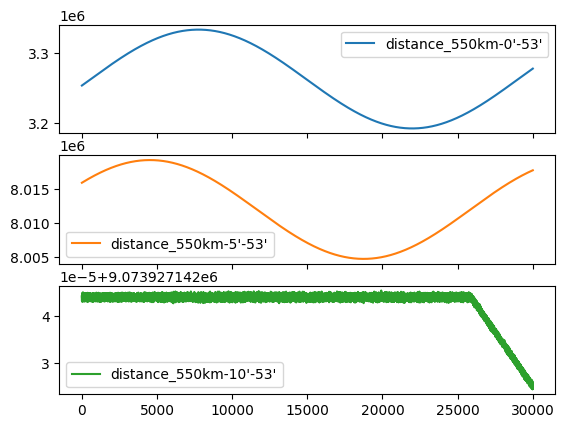

In [6]:
base_sattelite_positions[distance_suffixes].plot(subplots=True)

In [7]:
base_min_satellite = np.random.choice(df['satelliteId'].unique())
base_min_satellite

'Starlink-0-2'

In [8]:
base_min_sattelite_positions = df[df.satelliteId == base_min_satellite].reset_index()[['TimeStamp', 'X', 'Y', 'Z']]
min_distance_suffixes = []
for orbit in df['orbitId'].unique():
    orbit_satellites = df[df.orbitId == orbit].reset_index()[['TimeStamp', 'X', 'Y', 'Z']]
    orbit_satellites["distance"] = orbit_satellites.apply(lambda row: np.sqrt(
                    (row.X - base_min_sattelite_positions.X[row.name // NUMBER_OF_SATELLITES_PER_ORBIT])**2 + 
                    (row.Y - base_min_sattelite_positions.Y[row.name // NUMBER_OF_SATELLITES_PER_ORBIT])**2 + 
                    (row.Z - base_min_sattelite_positions.Z[row.name // NUMBER_OF_SATELLITES_PER_ORBIT])**2), axis=1)
    orbit_satellites_min_distance = orbit_satellites.groupby('TimeStamp').min().reset_index()
    base_min_sattelite_positions[f"min_distance_{orbit}"] = orbit_satellites_min_distance.distance
    min_distance_suffixes.append(f"min_distance_{orbit}")

base_min_sattelite_positions

,TimeStamp,X,Y,Z,min_distance_550km-0'-53',min_distance_550km-5'-53',min_distance_550km-10'-53'
0,0,5.828318e+06,2.254178e+06,2.991395e+06,0.0,754841.216248,1.089281e+06
1,100,5.827904e+06,2.254565e+06,2.991909e+06,0.0,754826.872945,1.089238e+06
2,200,5.827490e+06,2.254953e+06,2.992423e+06,0.0,754812.527334,1.089195e+06
3,300,5.827076e+06,2.255340e+06,2.992938e+06,0.0,754798.179415,1.089152e+06
4,400,5.826662e+06,2.255728e+06,2.993452e+06,0.0,754783.829188,1.089109e+06
...,...,...,...,...,...,...,...
29996,2999600,-5.101666e+06,-2.820970e+06,-3.743553e+06,0.0,730111.821018,1.016176e+06
29997,2999700,-5.101148e+06,-2.821309e+06,-3.744003e+06,0.0,730094.648072,1.016125e+06
29998,2999800,-5.100630e+06,-2.821648e+06,-3.744453e+06,0.0,730077.473844,1.016075e+06
29999,2999900,-5.100112e+06,-2.821987e+06,-3.744903e+06,0.0,730060.298338,1.016024e+06


array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object)

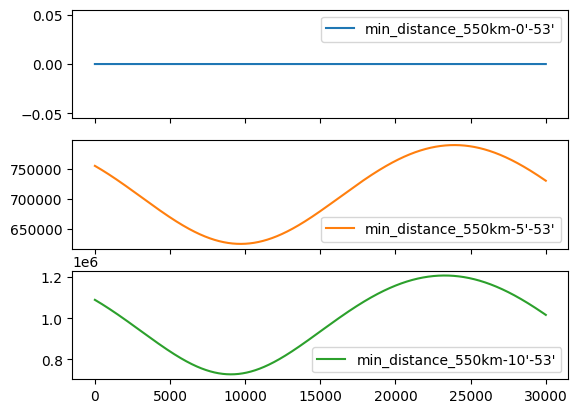

In [9]:
base_min_sattelite_positions[min_distance_suffixes].plot(subplots=True)